In [150]:
import itertools
import pickle
import torch
from tqdm import tqdm
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from torch import nn
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
device = "cuda" if torch.cuda.is_available() else "cpu"

#### Define dataset loader

In [151]:
def get_transform_rainfall(grayscale=False, convert=True):
    transform_list = []
    if grayscale:
        transform_list.append(transforms.Grayscale(1))
    if convert:
        transform_list += [transforms.ToTensor()]
        if grayscale:
            transform_list += [transforms.Normalize((0.5,), (0.5,))]
        else:
            transform_list += [transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]
    return transforms.Compose(transform_list)

class RainfallDataset(Dataset):
    def __init__(self, pickle_file_A, pickle_file_B, input_nc, output_nc) -> None:
        super(RainfallDataset, self).__init__()
        self.dir_A = pickle_file_A
        self.dir_B = pickle_file_B
        with open(self.dir_A, "rb") as f:
            data_A = pickle.load(f)
            self.A_dates = list(data_A.keys())
            self.A_images = list(data_A.values())
        with open(self.dir_B, "rb") as f:
            data_B = pickle.load(f)
            self.B_dates = list(data_B.keys())
            self.B_images = list(data_B.values())
        self.A_size = len(self.A_images)
        self.B_size = len(self.B_images)
        self.transform_A = get_transform_rainfall(grayscale=(input_nc == 1))
        self.transform_B = get_transform_rainfall(grayscale=(output_nc == 1))

    def __len__(self):
        """Return the total number of images in the dataset.

        As we have two datasets with potentially different number of images,
        we take a maximum of
        """
        return max(self.A_size, self.B_size)
    
    def __getitem__(self, index):
        """Return a data point and its metadata information.

        Parameters:
            index (int)      -- a random integer for data indexing

        Returns a dictionary that contains A, B, A_paths, and B_paths
            A (tensor)       -- an image in the input domain
            B (tensor)       -- its corresponding image in the target domain
            A_paths (str)    -- image paths
            B_paths (str)    -- image paths
        """
        # index_A = index % self.A_size
        # index_B = index % self.B_size
        # A_date = self.A_dates[index_A]
        # B_date = self.B_dates[index_B]
        A_image = self.A_images[index]
        B_image = self.B_images[index]

        A_img = Image.fromarray(A_image[2])
        B_img = Image.fromarray(B_image)

        A = self.transform_A(A_img)
        B = self.transform_B(B_img)

        # A_date_ts = torch.tensor(A_date.timestamp())
        # B_date_ts = torch.tensor(B_date.timestamp())

        return A, B

In [152]:
class ResnetBlock(nn.Module):
    """Define a Resnet block"""

    def __init__(self, dim, padding_type, use_dropout, use_bias):
        """Initialize the Resnet block

        A resnet block is a conv block with skip connections
        We construct a conv block with build_conv_block function,
        and implement skip connections in <forward> function.
        Original Resnet paper: https://arxiv.org/pdf/1512.03385.pdf
        """
        super(ResnetBlock, self).__init__()
        self.conv_block = self.build_conv_block(dim, padding_type, use_dropout, use_bias)

    def build_conv_block(self, dim, padding_type, use_dropout, use_bias):
        """Construct a convolutional block.

        Parameters:
            dim (int)           -- the number of channels in the conv layer.
            padding_type (str)  -- the name of padding layer: reflect | replicate | zero
            norm_layer          -- normalization layer
            use_dropout (bool)  -- if use dropout layers.
            use_bias (bool)     -- if the conv layer uses bias or not

        Returns a conv block (with a conv layer, a normalization layer, and a non-linearity layer (ReLU))
        """
        conv_block = []
        p = 0
        if padding_type == "reflect":
            conv_block += [nn.ReflectionPad2d(1)]
        elif padding_type == "replicate":
            conv_block += [nn.ReplicationPad2d(1)]
        elif padding_type == "zero":
            p = 1
        else:
            raise NotImplementedError("padding [%s] is not implemented" % padding_type)

        conv_block += [nn.Conv2d(dim, dim, kernel_size=3, padding=p, bias=use_bias), nn.BatchNorm2d(dim, affine=True, track_running_stats=True), nn.ReLU(True)]
        if use_dropout:
            conv_block += [nn.Dropout(0.5)]

        p = 0
        if padding_type == "reflect":
            conv_block += [nn.ReflectionPad2d(1)]
        elif padding_type == "replicate":
            conv_block += [nn.ReplicationPad2d(1)]
        elif padding_type == "zero":
            p = 1
        else:
            raise NotImplementedError("padding [%s] is not implemented" % padding_type)
        conv_block += [nn.Conv2d(dim, dim, kernel_size=3, padding=p, bias=use_bias), nn.BatchNorm2d(dim, affine=True, track_running_stats=True)]

        return nn.Sequential(*conv_block)

    def forward(self, X):
        """Forward function (with skip connections)"""
        out = X + self.conv_block(X)  # add skip connections
        return out

In [153]:
class CycleGAN(nn.Module):
    def __init__(self, input_nc=1, output_nc=1, ngf=16, n_resnet_blocks=6, padding_type="reflect", use_dropout=True, use_bias=True) -> None:
        super(CycleGAN, self).__init__()
        self.input_nc = input_nc
        self.output_nc = output_nc
        self.n_resnet_blocks = n_resnet_blocks
        self.use_bias = use_bias

        model = [nn.ReflectionPad2d(3), nn.Conv2d(input_nc, ngf, kernel_size=7, padding=0, bias=use_bias), nn.BatchNorm2d(ngf, affine=True, track_running_stats=True), nn.ReLU(True)]

        n_downsampling = 2
        for i in range(n_downsampling):  # add downsampling layers
            mult = 2**i
            model += [nn.Conv2d(ngf * mult, ngf * mult * 2, kernel_size=3, stride=2, padding=1, bias=use_bias), nn.BatchNorm2d(ngf * mult * 2, affine=True, track_running_stats=True), nn.ReLU(True)]

        mult = 2**n_downsampling
        for i in range(n_resnet_blocks):  # add ResNet blocks

            model += [ResnetBlock(ngf * mult, padding_type=padding_type, use_dropout=use_dropout, use_bias=use_bias)]

        for i in range(n_downsampling):  # add upsampling layers
            mult = 2 ** (n_downsampling - i)
            model += [nn.ConvTranspose2d(ngf * mult, int(ngf * mult / 2), kernel_size=3, stride=2, padding=1, output_padding=1, bias=use_bias), nn.BatchNorm2d(int(ngf * mult / 2), affine=True, track_running_stats=True), nn.ReLU(True)]
        model += [nn.ReflectionPad2d(3)]
        model += [nn.Conv2d(ngf, output_nc, kernel_size=7, padding=0)]
        model += [nn.Tanh()]

        self.model = nn.Sequential(*model)
        
    def forward(self, X):
        return self.model(X)


In [154]:
class Discriminator(nn.Module):
    def __init__(self, input_nc, n_layers=3, ndf=16, use_bias=True) -> None:
        super(Discriminator, self).__init__()
        kw = 4
        padw = 1
        nf_mult = 1
        nf_mult_prev = 1
        sequence = [nn.Conv2d(input_nc, ndf, kernel_size=kw, stride=2, padding=padw), nn.LeakyReLU(0.2, True)]
        for n in range(1, n_layers):  # gradually increase the number of filters
            nf_mult_prev = nf_mult
            nf_mult = min(2**n, 8)
            sequence += [nn.Conv2d(ndf * nf_mult_prev, ndf * nf_mult, kernel_size=kw, stride=2, padding=padw, bias=use_bias), nn.BatchNorm2d(ndf * nf_mult, affine=True, track_running_stats=True), nn.LeakyReLU(0.2, True)]

        nf_mult_prev = nf_mult
        nf_mult = min(2**n_layers, 8)
        sequence += [nn.Conv2d(ndf * nf_mult_prev, ndf * nf_mult, kernel_size=kw, stride=1, padding=padw, bias=use_bias), nn.BatchNorm2d(ndf * nf_mult, affine=True, track_running_stats=True), nn.LeakyReLU(0.2, True)]

        sequence += [nn.Conv2d(ndf * nf_mult, 1, kernel_size=kw, stride=1, padding=padw)]  # output 1 channel prediction map
        self.model = nn.Sequential(*sequence)

    def forward(self, X):
        return self.model(X)

In [155]:
class GANLoss(nn.Module):
    """Define different GAN objectives.

    The GANLoss class abstracts away the need to create the target label tensor
    that has the same size as the input.
    """

    def __init__(self, gan_mode, target_real_label=1.0, target_fake_label=0.0):
        """Initialize the GANLoss class.

        Parameters:
            gan_mode (str) - - the type of GAN objective. It currently supports vanilla, lsgan, and wgangp.
            target_real_label (bool) - - label for a real image
            target_fake_label (bool) - - label of a fake image

        Note: Do not use sigmoid as the last layer of Discriminator.
        LSGAN needs no sigmoid. vanilla GANs will handle it with BCEWithLogitsLoss.
        """
        super(GANLoss, self).__init__()
        self.real_label = torch.tensor(target_real_label).to(device)
        self.fake_label = torch.tensor(target_fake_label).to(device)
        self.gan_mode = gan_mode
        if gan_mode == "lsgan":
            self.loss = nn.MSELoss()
        elif gan_mode == "vanilla":
            self.loss = nn.BCEWithLogitsLoss()
        elif gan_mode in ["wgangp"]:
            self.loss = None
        else:
            raise NotImplementedError("gan mode %s not implemented" % gan_mode)

    def get_target_tensor(self, prediction, target_is_real):
        """Create label tensors with the same size as the input.

        Parameters:
            prediction (tensor) - - tpyically the prediction from a discriminator
            target_is_real (bool) - - if the ground truth label is for real images or fake images

        Returns:
            A label tensor filled with ground truth label, and with the size of the input
        """

        if target_is_real:
            target_tensor = self.real_label
        else:
            target_tensor = self.fake_label
        return target_tensor.expand_as(prediction)

    def __call__(self, prediction, target_is_real):
        """Calculate loss given Discriminator's output and grount truth labels.

        Parameters:
            prediction (tensor) - - tpyically the prediction output from a discriminator
            target_is_real (bool) - - if the ground truth label is for real images or fake images

        Returns:
            the calculated loss.
        """
        if self.gan_mode in ["lsgan", "vanilla"]:
            target_tensor = self.get_target_tensor(prediction, target_is_real)
            loss = self.loss(prediction, target_tensor)
        elif self.gan_mode == "wgangp":
            if target_is_real:
                loss = -prediction.mean()
            else:
                loss = prediction.mean()
        return loss


In [156]:
INPUT_NC = 1
OUTPUT_NC = 1
NDF = 16
NGF = 16
USE_BIAS = False
DISCRIMINATOR_LAYERS = 3
N_RESNET_LAYERS = 6
PADDING_TYPE = "reflect"
USE_DROPOUT = True
GAN_MODE = "lsgan"
LEARNING_RATE = 0.0002
BETA_1 = 0.5
BETA_2 = 0.999
EPOCHS = 5
BATCH_SIZE = 16
PICKLE_FILE_PATH_A = "./data/final_era5.pkl"
PICKLE_FILE_PATH_B = "./data/final_chirps.pkl"
LAMBDA_A = 50 # weight for cycle loss (A -> B -> A)
LAMBDA_B = 50 # weight for cycle loss (B -> A -> B)

##### Define Genrators and Discrimintaors

In [157]:
torch.manual_seed(88)
torch.cuda.manual_seed(88)
G_A = CycleGAN(
    INPUT_NC,
    OUTPUT_NC,
    NGF,
    N_RESNET_LAYERS,
    PADDING_TYPE,
    USE_DROPOUT,
    USE_BIAS
)

G_B = CycleGAN(
    OUTPUT_NC,
    INPUT_NC,
    NGF,
    N_RESNET_LAYERS,
    PADDING_TYPE,
    USE_DROPOUT,
    USE_BIAS
)

D_A = Discriminator(
    INPUT_NC, 
    DISCRIMINATOR_LAYERS, 
    NDF, 
    USE_BIAS
)

D_B = Discriminator(
    OUTPUT_NC, 
    DISCRIMINATOR_LAYERS, 
    NDF, 
    USE_BIAS
)

##### Create dataloader

In [158]:
dataset = RainfallDataset(
    PICKLE_FILE_PATH_A,
    PICKLE_FILE_PATH_B,
    INPUT_NC,
    OUTPUT_NC
)

dataloader = DataLoader(dataset, BATCH_SIZE)

##### Define Loss Functions

In [159]:
criterionGAN = GANLoss(GAN_MODE).to(device)
criterionCycle = torch.nn.L1Loss()
criterionIdt = torch.nn.L1Loss()

##### Define Optimizers


In [160]:
optimizer_G = torch.optim.Adam(
    itertools.chain(G_A.parameters(), G_B.parameters()),
    lr=LEARNING_RATE,
    betas=(BETA_1, BETA_2)
)

optimizer_D = torch.optim.Adam(
    itertools.chain(D_A.parameters(), D_B.parameters()),
    lr=LEARNING_RATE,
    betas=(BETA_1, BETA_2)
)

## Training Loop

In [161]:
G_A.to(device)
D_A.to(device)
G_B.to(device)
D_B.to(device);

In [162]:
device = next(D_A.parameters()).device
print(device)

cuda:0


In [163]:
for epoch in range(1, EPOCHS+1):
    epoch_loss_G_A = 0.0
    epoch_loss_G_B = 0.0
    epoch_loss_D_A = 0.0
    epoch_loss_D_B = 0.0
    for real_A, real_B in tqdm(dataloader, desc=f"Epoch: {epoch}/{EPOCHS}", colour="GREEN"):
        # Put data in VRAM
        real_A = real_A.to(device)
        real_B = real_B.to(device)

        # 1. Forward pass
        # Generate fake and reconstruction images
        fake_B = G_A(real_A)
        fake_A = G_B(real_B)
        rec_A = G_B(fake_B)
        rec_B = G_A(fake_A)
        # pred_real_D_A = 
        # pred_fake_D_A = 
        # pred_real_D_B = 
        # pred_fake_D_B = 

        #################################
        # Training Discriminator
        #################################
        
        # 1. Enable training of Discriminators
        for param in D_A.parameters():
            param.requires_grad = True
        for param in D_B.parameters():
            param.requires_grad = True
        
        # 2. Zero grad discriminator optimizer
        optimizer_D.zero_grad()

        # 3. Calculate discriminator D_A losses
        # Calculate loss of discriminator on real images
        loss_D_A_real = criterionGAN(D_A(real_B), True)
        # Calculate loss of discriminator on fake images
        loss_D_A_fake = criterionGAN(D_A(fake_B).detach(), False)
        # 4. Claculatr gradient of D_A
        loss_D_A = (loss_D_A_real + loss_D_A_fake) * 0.5
        loss_D_A.backward()

        # 5. Calculate discriminator D_B losses
        loss_D_B_real = criterionGAN(D_B(real_A), True)
        # Calculate loss of discriminator on fake images
        loss_D_B_fake = criterionGAN(D_B(fake_A).detach(), False)
        # 6. Claculate gradient of D_B
        loss_D_B = (loss_D_B_real + loss_D_B_fake) * 0.5
        loss_D_B.backward()

        # 7. Update weights of D_A and D_B
        optimizer_D.step()

        ###################################
        # Training Generator
        ###################################

        # 2. Disable training of Discriminators by turning off gradient calculation
        for param in D_A.parameters():
            param.requires_grad = False
        for param in D_B.parameters():
            param.requires_grad = False
        
        # 4. Zero grad genreator optimizer
        optimizer_G.zero_grad()
        
        # 3. Calculate generator loss | G_A and G_B
        lambda_idt = 0.5 * (LAMBDA_A + LAMBDA_B)
        loss_idt_A = criterionIdt(G_A(real_B), real_B) * lambda_idt
        loss_idt_B = criterionIdt(G_B(real_A), real_A) * lambda_idt

        # GAN loss D_A(G_A(A))
        loss_G_A = criterionGAN(D_A(fake_B), True)
        # GAN loss D_B(G_B(B))
        loss_G_B = criterionGAN(D_B(fake_A), True)
        # Forward cycle loss || G_B(G_A(A)) - A||
        loss_cycle_A = criterionCycle(rec_A, real_A) * LAMBDA_A
        # Backward cycle loss || G_A(G_B(B)) - B||
        loss_cycle_B = criterionCycle(rec_B, real_B) * LAMBDA_B
        # combined loss and calculate gradients
        loss_G = loss_G_A + loss_G_B + loss_cycle_A + loss_cycle_B + loss_idt_A + loss_idt_B
        
        # 5. Claculate generator gradients
        loss_G.backward()

        # 6. Update generator parameters
        optimizer_G.step()

        epoch_loss_G_A = loss_G_A.detach()
        epoch_loss_G_B = loss_G_B.detach()
        epoch_loss_D_A = loss_D_A.detach()
        epoch_loss_D_B = loss_D_B.detach()
        
    # See whats happenin'
    if epoch % 1 == 0:
        tqdm.write(f"D_A = {epoch_loss_D_A:0.4f} G_A = {epoch_loss_G_A:0.4f} | D_B = {epoch_loss_D_B:0.4f} G_B = {epoch_loss_G_B:0.4f}\n")

Epoch: 1/5: 100%|██████████| 123/123 [00:03<00:00, 35.02it/s]


D_A = 0.5027 G_A = 0.0031 | D_B = 0.4981 G_B = 0.0027



Epoch: 2/5: 100%|██████████| 123/123 [00:03<00:00, 35.70it/s]


D_A = 0.5013 G_A = 0.0017 | D_B = 0.5010 G_B = 0.0015



Epoch: 3/5: 100%|██████████| 123/123 [00:03<00:00, 35.65it/s]


D_A = 0.4994 G_A = 0.0011 | D_B = 0.5039 G_B = 0.0011



Epoch: 4/5: 100%|██████████| 123/123 [00:03<00:00, 35.73it/s]


D_A = 0.4965 G_A = 0.0008 | D_B = 0.5053 G_B = 0.0009



Epoch: 5/5: 100%|██████████| 123/123 [00:03<00:00, 35.63it/s]


D_A = 0.4939 G_A = 0.0006 | D_B = 0.5065 G_B = 0.0009



### Testing

In [164]:
G_A.eval()
real_A, real_B = None, None
with torch.inference_mode():
    for A, B in dataset:
        real_A, real_B = A.to(device), B.to(device)
        break
    fake_B = G_A(real_A.unsqueeze(dim=0))
img = fake_B

Text(0.5, 1.0, 'Real')

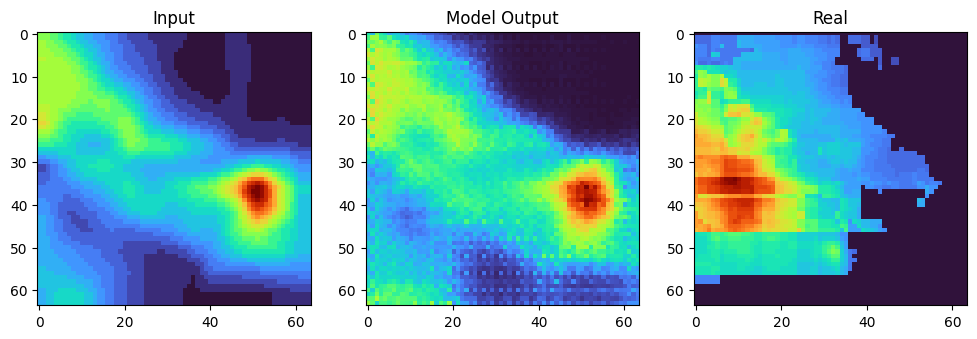

In [165]:
fig, axs = plt.subplots(1, 3, figsize=(12, 7))
axs[0].imshow(real_A.squeeze().cpu(), cmap="turbo")
axs[0].set_title("Input")
axs[1].imshow((img.squeeze().cpu() + 1)/2*255, cmap="turbo")
axs[1].set_title("Model Output")
axs[2].imshow(real_B.squeeze().cpu(), cmap="turbo")
axs[2].set_title("Real")